In [1]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
uploaded = files.upload()

for fn in uploaded.keys():
  print('"{name}" carregado com sucesso'.format(name=fn))

csv_filename = list(uploaded.keys())[0]
print(f"Arquivo '{csv_filename}' carregado")

df = pd.read_csv(csv_filename)
display(df.head())

Saving simulation_data_20251209_195457.csv to simulation_data_20251209_195457.csv
"simulation_data_20251209_195457.csv" carregado com sucesso
Arquivo 'simulation_data_20251209_195457.csv' carregado


,frame,active_agents,colliding_agents,warning_agents,mean_speed
0,0,20,0,0,2.000000
1,1,19,2,4,1.843296
2,2,19,2,4,1.843296
3,3,19,2,4,1.843296
4,4,19,2,4,1.843296


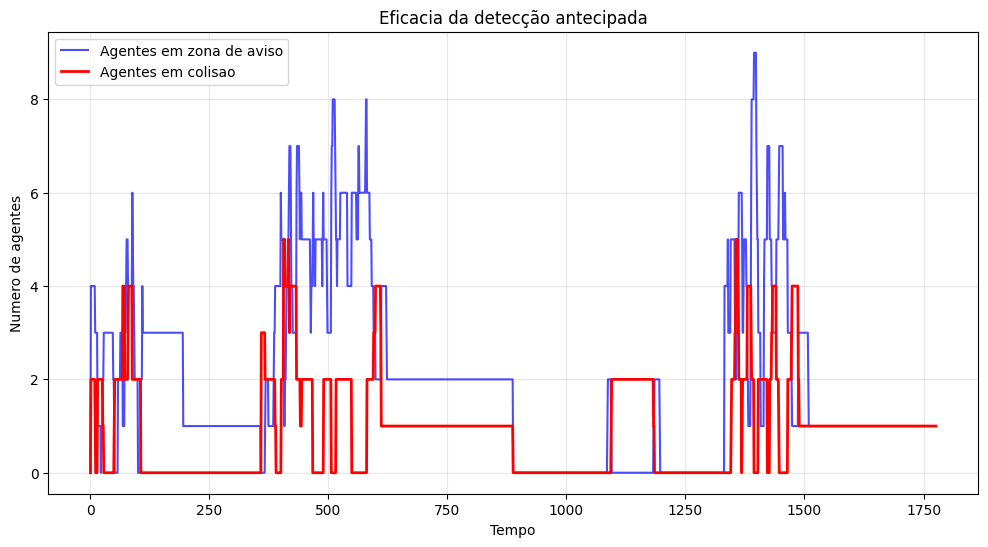

In [3]:
plt.figure(figsize=(12, 6))

plt.plot(df['frame'], df['warning_agents'], label='Agentes em zona de aviso', color='blue', alpha=0.7)
plt.plot(df['frame'], df['colliding_agents'], label='Agentes em colisao ', color='red', linewidth=2)

plt.title('Eficacia da detecção antecipada')
plt.xlabel('Tempo')
plt.ylabel('Numero de agentes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

A linha azul é o sistema de alerta, basicamente representa o disparo dos agentes próximos do raio definido para cada um, onde ainda não se tocaram


A linha vermelha representa os realmente ocasionaram uma colisão

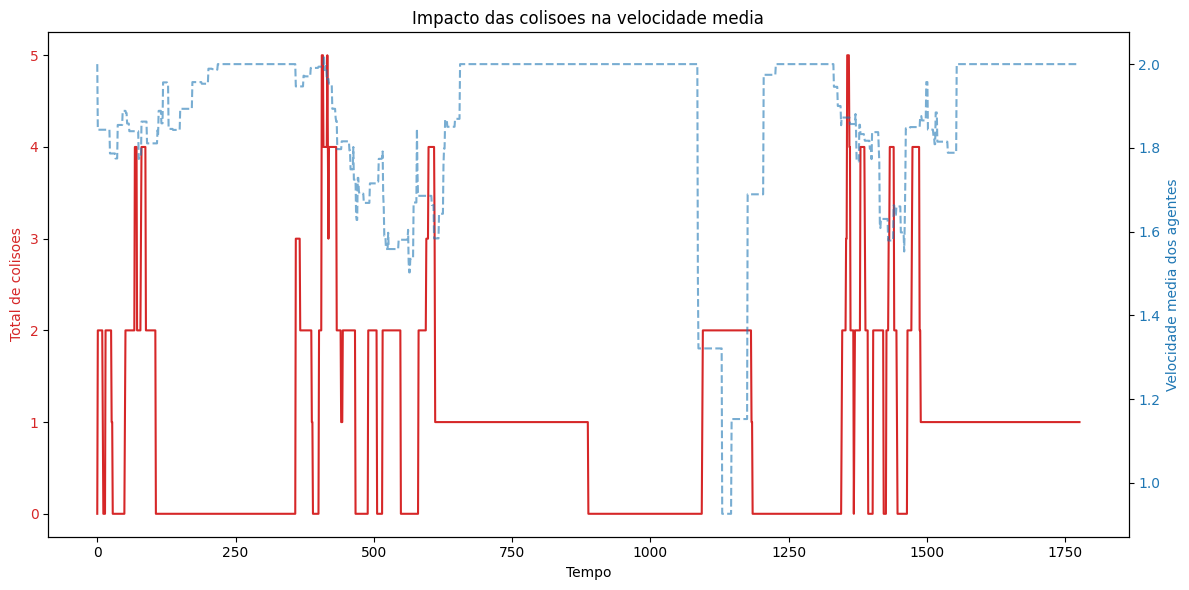

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Tempo')
ax1.set_ylabel('Total de colisoes', color=color)
ax1.plot(df['frame'], df['colliding_agents'], color=color, label='colisoes')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Velocidade media dos agentes', color=color)
ax2.plot(df['frame'], df['mean_speed'], color=color, linestyle='--', alpha=0.6, label='velocidade media')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impacto das colisoes na velocidade media')
fig.tight_layout()
plt.show()

Linha vermelha é as colisões por agentes

Linha azul é a velocidade média por agentes, basicamente passando a ideia do desempenho do sistema, que tem uma queda quando ele o sistema ativa a lógica de ajustar a direção ou a velocidade, ou seja, quando a ideia é consertar as colisões